In [9]:
!pip install pandas scikit-learn catboost xgboost seaborn matplotlib joblib

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from catboost import CatBoostRegressor
from catboost import CatBoostClassifier
from xgboost import XGBRegressor
import joblib, os, warnings, seaborn as sns, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [13]:
df = pd.read_csv("cars_feature_engineered.csv")

# quick sanity checks
print(df.shape)
print(df.isna().sum().sort_values(ascending=False)[:10])
print(df.select_dtypes("object").nunique().sort_values(ascending=False)[:10])

# drop obvious leakage or unusable columns
drop_cols = ["vin", "saledate", "price_diff"]   # price_diff = target leakage
df = df.drop(columns=drop_cols)

# separate target
y = df["sellingprice"]
X = df.drop(columns=["sellingprice"])

(472325, 22)
year                0
make                0
sale_month          0
sale_year           0
mileage_per_year    0
car_age             0
price_diff          0
saledate            0
sellingprice        0
mmr                 0
dtype: int64
vin         465768
seller       11923
saledate      3609
trim          1494
model          768
make            53
state           34
color           20
interior        17
body             9
dtype: int64


In [15]:
#Identify column types
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print(f"{len(cat_cols)} categorical  : {cat_cols}")
print(f"{len(num_cols)} numerical    : {num_cols}")

9 categorical  : ['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior', 'seller']
9 numerical    : ['year', 'condition', 'odometer', 'mmr', 'car_age', 'mileage_per_year', 'sale_year', 'sale_month', 'sale_day']


In [19]:
#Split for test and training before any preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [23]:
#Helper for eval
def regression_report(model, X_tr, y_tr, X_te, y_te, name="model"):
    preds_tr = model.predict(X_tr)
    preds_te = model.predict(X_te)
    mae_tr  = mean_absolute_error(y_tr, preds_tr)
    mae_te  = mean_absolute_error(y_te, preds_te)
    rmse_tr = mean_squared_error(y_tr, preds_tr, squared=False)
    rmse_te = mean_squared_error(y_te, preds_te, squared=False)
    print(f"{name:15s} | MAE train {mae_tr:7.0f}  test {mae_te:7.0f} | RMSE train {rmse_tr:8.0f}  test {rmse_te:8.0f}")
    return {"mae_te": mae_te, "rmse_te": rmse_te}

In [35]:
cb_model = CatBoostRegressor(
    iterations=400,
    depth=8,           # Reduce from 10 for ~20-30% faster (trade-off: slight accuracy drop)
    learning_rate=0.1, # Default; increase to 0.2 for fewer iterations
    random_seed=RANDOM_STATE,
    thread_count=8,    # Match your CPU cores (check via `import os; os.cpu_count()`)
    task_type='CPU',   # Explicit; switch to 'GPU' if NVIDIA + CUDA installed (pip install catboost[gpu])
    verbose=50         # Log every 50 iterations—shows progress!
)
cb_model.fit(X_train, y_train, cat_features=cat_cols)
cb_scores = regression_report(cb_model, X_train, y_train, X_test, y_test, "CatBoost")

0:	learn: 8750.1342790	total: 3.23s	remaining: 21m 30s
50:	learn: 1823.1579811	total: 2m 9s	remaining: 14m 48s
100:	learn: 1730.1246201	total: 3m 47s	remaining: 11m 13s
150:	learn: 1659.3234916	total: 5m 31s	remaining: 9m 7s
200:	learn: 1611.3879039	total: 7m 25s	remaining: 7m 21s
250:	learn: 1576.9895606	total: 9m 13s	remaining: 5m 28s
300:	learn: 1541.2635847	total: 11m 8s	remaining: 3m 39s
350:	learn: 1518.0380621	total: 13m 5s	remaining: 1m 49s
399:	learn: 1495.9772003	total: 14m 55s	remaining: 0us
CatBoost        | MAE train     889  test     900 | RMSE train     1543  test     1575


Accuracy: 0.947
Precision: 0.947
Recall: 0.947

Full Report:
               precision    recall  f1-score   support

        High       0.93      0.92      0.93      9637
         Low       0.95      0.95      0.95     35864
      Medium       0.95      0.95      0.95     48964

    accuracy                           0.95     94465
   macro avg       0.94      0.94      0.94     94465
weighted avg       0.95      0.95      0.95     94465



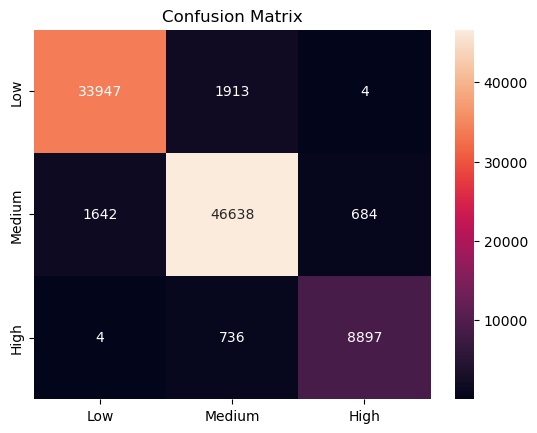

In [43]:
# Assuming X_train, X_test, y_train, y_test, cat_cols from before
# Bin prices into 3 classes (adjust bins based on y.describe())
bins = [0, 10000, 25000, np.inf]  # Low/Med/High
labels = ['Low', 'Medium', 'High']
y_train_binned = pd.cut(y_train, bins=bins, labels=labels, include_lowest=True)
y_test_binned = pd.cut(y_test, bins=bins, labels=labels, include_lowest=True)

# Fit classifier (similar to regressor)
cbc = CatBoostClassifier(
    iterations=400,
    depth=8,
    random_seed=RANDOM_STATE,
    verbose=0,
    cat_features=cat_cols  # Same as before
)
cbc.fit(X_train, y_train_binned)

# Predict
y_pred_binned = cbc.predict(X_test)

# Compute metrics (multi-class: average='macro' for balanced, or 'weighted' for imbalanced)
accuracy = accuracy_score(y_test_binned, y_pred_binned)
precision = precision_score(y_test_binned, y_pred_binned, average='weighted')  # Handles multi-class
recall = recall_score(y_test_binned, y_pred_binned, average='weighted')

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print("\nFull Report:\n", classification_report(y_test_binned, y_pred_binned))

# Optional: Confusion matrix plot
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.show()